In [ ]:
# !pip install git+https://github.com/collinleiber/ClustPy.git      &> /dev/null
!pip install clustpy      &> /dev/null

# Descargar SOLO el archivo donde está cvnn_score desde GitHub
!wget -q -O _metrics_utils_dev.py \
https://raw.githubusercontent.com/collinleiber/ClustPy/main/clustpy/metrics/_metrics_utils.py

!wget -q -O internal_clustering_metrics_dev.py \
https://raw.githubusercontent.com/collinleiber/ClustPy/main/clustpy/metrics/internal_clustering_metrics.py

In [ ]:
#@title Métrica interna CVNN desde Clustpy

# from sklearn.neighbors import NearestNeighbors
# from scipy.spatial.distance import pdist
# import numpy as np
# from sklearn.metrics.cluster._supervised import check_clusterings
# from sklearn.utils import check_X_y

# def _check_length_data_and_labels(X: np.ndarray, labels: np.ndarray):
#     """
#     Check that the data and the prediction labels are compatible.
#     If they do not match throw an exception.

#     Parameters
#     ----------
#     X : np.ndarray
#         The data set
#     labels : np.ndarray
#         The labels as predicted by a clustering algorithm

#      Returns
#     -------
#     tuple : (np.ndarray, np.ndarray)
#         The data set,
#         The predicted labels
#     """
#     X, labels = check_X_y(X, labels)
#     labels = labels.astype(int)
#     n_pred_clusters = len(np.unique(labels))
#     if n_pred_clusters == 1 or n_pred_clusters == X.shape[0]:
#         raise ValueError("The number of different labels must be within [2, n_samples -1]")
#     return X, labels

# def cvnn_score(X: np.ndarray, labels: np.ndarray | int | tuple, n_neighbors: int = 5, metric: str = "euclidean") -> float | np.ndarray:
#     """
#     Evaluate the quality of predicted labels by computing the clustering validation index based on nearest neighbors (CVNN).
#     The score is calculated by adding a nearest-neighbor-based cluster separation value with a cluster compactness vale based on inner-cluster distances.
#     Usually, it is used with a list of label arrays, i.e., labels is of type list or tuple.
#     In this case, the score will be normalized to a value within [0, 2].
#     If labels is a single array (of type np.ndarray) a single score is returned that is not normalized.
#     In both cases, a lower value indicates a better clustering result (less neighbors in separate clusters and lower inner-cluster distances).

#     Parameters
#     ----------
#     X : np.ndarray
#         The data set
#     labels : np.ndarray | list | tuple
#         The labels as predicted by a clustering algorithm. If labels is a list/tuple it should contain multiple labels arrays of type np.ndarray
#     n_neighbors : int
#         The amount of neighbors to consider when calculating the cluster separation score. An object is not considered its own neighbor (default: 5)
#     metric : str
#         The metric used to identify the neighbors and to calculate the inner-cluster distance.
#         See scipy.spatial.distance.pdist for more information (default: 'euclidean')

#     Returns
#     -------
#     cvnn : float | np.ndarray
#         The cvnn score of type float if labels contains a single labels array, i.e., labels is of type np.ndarray.
#         Alternatively, a np.ndarray containing the normalized cvnn scores.

#     References
#     -------
#     Liu, Yanchi, et al. "Understanding and enhancement of internal clustering validation measures."
#     IEEE transactions on cybernetics 43.3 (2013): 982-994.
#     """
#     def _internal_cvnn_score(X: np.ndarray, labels: np.ndarray, nrbs_indices: np.ndarray, metric: str) -> (float, float):
#         """
#         The real calculation method of the CVNN score.

#         Parameters
#         ----------
#         X : np.ndarray
#             The data set
#         labels : np.ndarray
#             The given labels
#         nrbs_indices : np.ndarray
#             The indicices of the nearest neighbors for each point. Has shape n_samples x n_neighbors
#         metric : str
#             The metric used to calculate the inner-cluster distance.

#         Returns
#         -------
#         tuple : (float, float)
#             The cluster spearation and cluster compactness value
#         """
#         X, labels = _check_length_data_and_labels(X, labels)
#         assert isinstance(labels, np.ndarray), "labels must be of type np.nddary. Your input has type {0}".format(type(labels))
#         unique_clusters = np.unique(labels)
#         # Calculate neighbor weights
#         n_neighbors = nrbs_indices.shape[1]
#         n_neighbors_not_in_cluster = (labels.reshape((-1, 1)) != labels[nrbs_indices]).mean(1)
#         cluster_separation_scores = np.zeros(unique_clusters.shape[0])
#         cluster_compactness_scores = np.zeros(unique_clusters.shape[0])
#         # Do per-cluster calculations
#         for i, c in enumerate(unique_clusters):
#             in_cluster = (labels == c)
#             # Calculate separation (mean of neighbor weights in cluster)
#             cluster_separation_scores[i] = n_neighbors_not_in_cluster[in_cluster].mean()
#             # Calculate compartness (mean of pair-wise distances in cluster)
#             X_in_cluster = X[in_cluster]
#             if X_in_cluster.shape[0] > 1:
#                 cluster_distances = pdist(X_in_cluster, metric=metric)
#                 cluster_compactness_scores[i] = cluster_distances.mean()
#             else:
#                 cluster_compactness_scores[i] = 0
#         # Calculate final CVNN
#         cluster_separation_final = cluster_separation_scores.max()
#         cluster_compactness_final = cluster_compactness_scores.sum()
#         return cluster_separation_final, cluster_compactness_final

#     # Compute nearest neighbors
#     nbrs = NearestNeighbors(n_neighbors=n_neighbors, metric=metric).fit(X)
#     _, nrbs_indices = nbrs.kneighbors()
#     # Get CVNN
#     if isinstance(labels, list) or isinstance(labels, tuple):
#         # Calculate cluster separation and cluster compactness for each labels array in the list
#         n_labels = len(labels)
#         cluster_separations = np.zeros(n_labels)
#         cluster_compactnesses = np.zeros(n_labels)
#         for i, l in enumerate(labels):
#             cluster_separation_l, cluster_compactness_l = _internal_cvnn_score(X, l, nrbs_indices, metric)
#             cluster_separations[i] = cluster_separation_l
#             cluster_compactnesses[i] = cluster_compactness_l
#         # Normalize scores
#         max_cluster_separations = cluster_separations.max()
#         max_cluster_compactnesses = cluster_compactnesses.max()
#         if max_cluster_separations != 0 and max_cluster_compactnesses != 0:
#             cvnn = cluster_separations / max_cluster_separations + cluster_compactnesses / max_cluster_compactnesses
#         else:
#             cvnn = 0
#     elif isinstance(labels, np.ndarray):
#         # Do not normalize scores
#         cluster_separation, cluster_compactness = _internal_cvnn_score(X, labels, nrbs_indices, metric)
#         cvnn = cluster_separation + cluster_compactness
#     else:
#         raise ValueError("The labels must be of type list/tuple (indicating a list of different labels) or np.ndarray (indicating a single labels array). Your input is {0}".format(type(labels)))
#     return cvnn

In [ ]:
import torch
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
import torch.nn.functional as F
from torch.optim.lr_scheduler import ReduceLROnPlateau

# ======================= Componentes ClustPy =======================
from clustpy.deep import DEC, IDEC
from clustpy.deep.neural_networks._abstract_autoencoder import _AbstractAutoencoder
from clustpy.deep.neural_networks import FeedforwardAutoencoder
from clustpy.data import z_normalization
# import clustpy

# Métricas externas de validación
from clustpy.metrics import (
    unsupervised_clustering_accuracy,
    purity,
    fair_normalized_mutual_information,
    variation_of_information,
    pc_f1_score,
    pc_rand_score,
    ConfusionMatrix
)

from sklearn.metrics import (
    # Métricas externas de sklearn
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score, completeness_score, v_measure_score,
    adjusted_mutual_info_score,
    # Métricas internas de clustering no supervisadas
    silhouette_score,
    calinski_harabasz_score,
    davies_bouldin_score
)
from sklearn.metrics import silhouette_samples

# Algoritmos de componentes principales
from sklearn.manifold import TSNE
# from sklearn.decomposition import PCA

import os
import numpy as np
import time
# import random
# import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines  import Line2D

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import importlib.util
import sys

# Cargar la dependencia privada que necesita cvnn_score
spec_utils = importlib.util.spec_from_file_location("clustpy.metrics._metrics_utils", "_metrics_utils_dev.py")
_metrics_utils_dev = importlib.util.module_from_spec(spec_utils)

# Registrar el módulo con el nombre que espera el archivo que contiene la métrica CVNN
sys.modules["clustpy.metrics._metrics_utils"] = _metrics_utils_dev
spec_utils.loader.exec_module(_metrics_utils_dev)     # Ejecutar el módulo

# Ahora cargamos el archivo donde se encuentra la métrica CVNN
spec = importlib.util.spec_from_file_location("internal_clustering_metrics_dev", "internal_clustering_metrics_dev.py")
internal_clustering_metrics_dev = importlib.util.module_from_spec(spec)
spec.loader.exec_module(internal_clustering_metrics_dev)

# Extraemos la función que implementa la métrica
cvnn_score = internal_clustering_metrics_dev.cvnn_score

In [ ]:
# Semilla para controlar la aleatoriedad estadística
seed = 42
def establecer_semilla(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)

    # random.seed(seed)
    np.random.seed(seed)

    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
# ------------------------------------------------------------------------------

establecer_semilla(seed)

g_torch = torch.Generator()     # Se cargan en los loaders
g_torch.manual_seed(seed)

# Configuración de dispositivo de ejecución de modelos PyTorch -----------------
#
os.environ["CLUSTPY_DEVICE"] = "cuda" if torch.cuda.is_available() else "cpu"
DEVICE = torch.device(os.environ["CLUSTPY_DEVICE"])
print(f"Dispositivo: {DEVICE}")

Dispositivo: cuda


In [ ]:
#@title Funciones para medir tiempo de cómputo
# ==============================================================================

def sincronizar_cuda():
    if torch.cuda.is_available():
        torch.cuda.synchronize()

def formatear_tiempo(segundos):
    minutos = int(segundos // 60)
    segundos_restantes = segundos % 60
    return f"{minutos} min {segundos_restantes:.2f} s"

In [ ]:
#@title CARGA DE DATOS: CIFAR-10
# =============================================================================

def cargar_cifar10(ruta: str = "./data", batch_size=2048):
    """
      Descarga CIFAR-10 y lo devuelve como arrays numpy listos para ClustPy.

      CIFAR-10 contiene 60000 imágenes RGB de 32×32 píxeles distribuidas en
      10 clases (avión, automóvil, pájaro, gato, ciervo, perro, rana, caballo,
      barco, camión).

      Este conjunto de datos tiene 50000 imágenes para entrenamiento y
      10000 para prueba.

      Preprocesamiento aplicado:
        - transforms.ToTensor() convierte cada imagen PIL (H×W×C, uint8 [0,255])
          a un tensor escalado de tipo de dato float32 (C×H×W, [0.0, 1.0]).
        - .view(N, -1) aplana cada imagen (3, 32, 32) convirtiéndola en un
          vector de 3072 características.
        - Por fuera de esta función, se aplica una normalización z-score con
          clustpy.data.z_normalization para mantener separadas las
          responsabilidades de carga y preprocesamiento.

      Params: -------------
        ruta : str
            Directorio donde se almacena (o descarga) el dataset.
            Por defecto "./data".

      Return: -------------
        X: np.ndarray de forma (N_imágenes, 3072 características), dtype float32
           Píxeles aplanados en rango [0, 1] antes de normalizar.
        y: np.ndarray de forma (N_imágenes,), dtype int32
           Etiquetas de clase (0-9). Se usan solo para evaluación posterior,
           NO durante el entrenamiento de DEC.
      """
    # ToTensor escala automáticamente de [0,255] uint8 → [0.0, 1.0] float32.
    # No se aplica normalización aquí. ClustPy la gestiona por separado.
    transform = transforms.ToTensor()

    train_set = datasets.CIFAR10(root=ruta, train=True,  download=True, transform=transform)
    test_set  = datasets.CIFAR10(root=ruta, train=False, download=True, transform=transform)

    def _to_numpy(dataset: torch.utils.data.Dataset):
        """
          Convierte un Dataset de PyTorch en arreglos de Numpy.

          Esta función recorre un dataset de PyTorch por lotes usando un DataLoader,
          extrae las imágenes y sus etiquetas, aplana cada imagen en un vector
          unidimensional y finalmente concatena todos los lotes

          Params:
            dataset : torch.utils.data.Dataset
                Dataset de torchvision con transform=ToTensor() ya aplicado.
                Parámetros

          Return:
            X_np : np.ndarray (N_imágenes, N_características) - Imágenes aplanadas
            y_np : np.ndarray (N_imágenes,) — Etiquetas
        """

        # DataLoader devuelve el dataset como un iterable por lotes (batches)
        # Se usa un batch_size=2048 para procesar 2048 imágenes por iteración y
        # para aprovechar el paralelismo de PyTorch
        loader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
        ### batch_size pequeño → más iteraciones, más lento, menor memoria por lote
        ### batch_size grande  → menos iteraciones, más rápido, mayor memoria por lote

        Xs, ys = [], []
        for imgs, labels in loader:
            # imgs tiene forma (batch, 3, 32, 32)
            Xs.append(imgs.view(imgs.size(0), -1).numpy())    # .view(batch, -1) lo aplana a (batch, 3072).
            ys.append(labels.numpy())
        return np.concatenate(Xs).astype(np.float32), np.concatenate(ys).astype(np.int32)
    # --------------------------------------------------------------------------

    X_train, y_train = _to_numpy(train_set)
    X_test, y_test = _to_numpy(test_set)

    # Concatenación de los datos de entrenamiento y prueba al ser algoritmo no supervisado
    X = np.concatenate([X_train, X_test]).astype(np.float32)   # (60000, 3072)
    y = np.concatenate([y_train, y_test]).astype(np.int32)     # (60000,)

    print(f"CIFAR-10 cargado — X: {X.shape}  y: {y.shape}")
    return X, y

In [ ]:
#@title AUTOENCODER
# =============================================================================

"""
  layers: list[int]
      Tamaños de capa desde la entrada hasta la capa de embedding.
      El decoder se inferirá como la lista invertida.

  batch_norm: bool
      Si True, agrega BatchNorm1d entre cada capa, para normalizar por mini-batch
      las activaciones o las salidas intermedias de la red. Estabiliza el entrenamiento,
      pero aumenta la complejidad del modelo.

  dropout: float | None (sin dropout)
      Fracción de neuronas a desactivar aleatoriamente durante el entrenamiento.

  activation_fn: torch.nn.Module
      Función de activación para las capas ocultas. LeakyReLU es el
      default de ClustPy porque evita el problema de neuronas muertas de ReLU.

  random_state: int | None
      Semilla para reproducibilidad en la inicialización de pesos.

  autoencoder_params: dict | None
        Parámetros del autoencoder a instanciar.
        Si None, se usa los parámetros base para CIFAR-10 con FeedforwardAutoencoder.
"""

def crear_autoencoder(
    autoencoder_class: type = FeedforwardAutoencoder,
    autoencoder_params: dict = {
        "layers":        [3072, 1024, 512, 256, 10],
        "batch_norm":    False,
        "dropout":       None,
        "activation_fn": torch.nn.LeakyReLU,
        "random_state":  seed,
    }
):
    """
      Instancia un autoencoder de ClustPy.
      La dimensión de la capa final, es decir, del embedding, coincide con el número de clases del dataset.

      Ejemplo de arquitectura del autoencoder FeedforwardAutoencoder (FullyConnectedBlock)
        Entrada → Capa oculta 1 →  Capa oculta 2 → Capa oculta 3 → Embedding
          3072  →    1024       →      512       →     256       →    10

      ClustPy construye automáticamente el decoder como el espejo simétrico del encoder.

      Params: --------------
        autoencoder_class: type (Default: FeedforwardAutoencoder)
              Clase del autoencoder a instanciar. Debe heredar de `_AbstractAutoencoder` (todos los autoencoders de ClustPy lo hacen).

      Return: --------------
        autoencoder: _AbstractAutoencoder
            Instancia lista para ser pasada a pre-entrenamiento y a DEC.
    """

    autoencoder = autoencoder_class(**autoencoder_params)

    n_params = sum(p.numel() for p in autoencoder.parameters())
    print(f"FeedforwardAutoencoder — parámetros totales: {n_params:,}")

    return autoencoder

In [ ]:
#@title Pre-entrenamiento manual con seguimiento de pérdida
# =============================================================================

"""
  Fase 1 — Pre-entrenamiento del autoencoder:
        El autoencoder se entrena con pérdida MSE de reconstrucción durante
        `pretrain_epochs` épocas. El objetivo es aprender un espacio latente
        compacto y significativo antes de aplicar clustering.
"""

def pretrain_with_tracking(
    autoencoder:      _AbstractAutoencoder,
    X:                np.ndarray,
    n_epochs:         int = 50,
    batch_size:       int = 256,
    optimizer_class:  torch.optim.Optimizer = torch.optim.Adam,
    optimizer_params: dict = {"lr": 1e-3},
    loss_name:        str = "mse",
    use_scheduler:    bool = False,
    generator_seed:   torch.Generator = g_torch
):
    """
      [Fase 1]: Pre-entrena el autoencoder de ClustPy registrando la función de pérdida media por época.

      Params:
        autoencoder: FeedforwardAutoencoder
            Instancia del autoencoder de ClustPy a pre-entrenar.
        X: np.ndarray (N_imágenes, N_características)
            Datos aplanados y normalizados de cada imagen. Este arreglo se convierte
            en tensor de PyTorch y se recorre por lotes aleatorios.
        n_epochs: int
            Número de épocas de pre-entrenamiento.
        batch_size: int
            Tamaño de mini-batch para iterar sobre los datos de entrenamiento.
        optimizer_class: torch.optim.Optimizer (Default Adam)
            Clase del optimizador a usar.
        optimizer_params: dict
            Parámetros del optimizador (p. ej. Tasa de aprendizaje 'lr', regularización L2 'weight_decay').
        loss_name: str (default 'mse')
            Tipo de función de pérdida para el entrenamiento del autoencoder ('mse', 'cros_sentropy', 'mae', 'smooth_l1').
        use_scheduler: bool (default False)
            Sirve para ajustar dinámicamente la tasa de aprendizaje a medida que el modelo se entrena.

      Return:
        losses: list[float]
            Lista con la pérdida MSE media de cada época.
    """

    autoencoder = autoencoder.to(DEVICE)
    optimizer = optimizer_class(autoencoder.parameters(), **optimizer_params)

    # Scheduler para reducir la tasa de aprendizaje cuando la pérdida se estanque
    scheduler = None
    if use_scheduler:
      scheduler = ReduceLROnPlateau(optimizer, mode="min", factor=0.5, patience=5)

    # Se convierten los datos a tensores y se recorren por lotes aleatorizados
    X_tensor = torch.from_numpy(X).float()
    loader = DataLoader(TensorDataset(X_tensor), batch_size=batch_size, shuffle=True, generator=generator_seed)

    # Función de pérdida
    loss_name = loss_name.lower()
    if loss_name == "mse":                # Error cuadrático medio
        loss_fn = torch.nn.MSELoss()
    elif loss_name == "cros_sentropy":    # Entropía cruzada para clasificación multiclase
        loss_fn = torch.nn.CrossEntropyLoss()
    elif loss_name == "l1" or "mae":      # Error absoluto medio
        loss_fn = torch.nn.L1Loss()
    elif loss_name == "smooth_l1":        # Mezcla el MSE y MAE (pérdida robusta)
        loss_fn = torch.nn.SmoothL1Loss()
    else:
        raise ValueError(f"Función de pérdida no reconocida: {loss_name}")

    losses = []           # Registro de pérdida
    autoencoder.train()   # Ponemos el autoencoder en modo de entrenamiento

    for epoch in range(1, n_epochs +1):
        epoch_loss = 0.0          # La pérdida se reinicializa por época
        for (batch,) in loader:
            batch = batch.to(DEVICE)
            z = autoencoder.encode(batch)       # Representación latente
            if isinstance(z, tuple):            # Un autoencoder variacional retorna (media, desviación)
                z = z[0]                        # Se usa solo la media para el embedding
            x_rec = autoencoder.decode(z)       # Deconstrucción del dato original
            # loss = F.mse_loss(x_rec, batch)     # Error cuadrático medio
            loss = loss_fn(x_rec, batch)
            optimizer.zero_grad()               # Reseteo de los gradientes por batch
            loss.backward()                     # Retropropagación para ajuste de parámetros por gradiente
            optimizer.step()                    # Actualización de pesos y sesgos
            epoch_loss += loss.item()           # Acumulación de la pérdida

        media = epoch_loss/len(loader)      # Promedio de la pérdida por época
        losses.append(media)

        if use_scheduler:
            scheduler.step(media)

        current_lr = optimizer.param_groups[0]['lr']

        # Registro de la pérdida promedio con las épocas
        if epoch % 10 == 0 or epoch == 1:
            if use_scheduler:
                print(f"  [Pretrain] Época {epoch:3d}/{n_epochs}  MSE: {media:.6f}  LR: {current_lr:.6f}")
            else:
                print(f"  [Pretrain] Época {epoch:3d}/{n_epochs}  MSE: {media:.6f}")

    # Cambiamos el flag interno de ClustPy para indicar que el autoencoder ya está listo
    autoencoder.fitted = True
    return np.array(losses)

In [ ]:
#@title Gráfico de pérdida sobre CIFAR-10
# =============================================================================

def grafico_perdida(pretrain_losses):
    """
      Genera el gráfico de pérdida MSE durante el pre-entrenamiento por época.

      Params:
        pretrain_losses: np.ndarray - Pérdida MSE por época
    """

    epocas = np.arange(1, len(pretrain_losses)+1)
    min_idx = int(np.argmin(pretrain_losses))
    min_val = pretrain_losses[min_idx]

    fig, ax = plt.subplots(figsize=(5, 4))

    ax.plot(epocas, pretrain_losses, color="#4363d8", linewidth=2.2, label="MSE Loss")
    ax.fill_between(epocas, pretrain_losses, alpha=0.12, color="#4363d8")

    # Marcador de mínimo
    # ax.axvline(min_idx+1, color="#e6194b", linestyle="--", linewidth=1.4, alpha=0.8)
    ax.scatter(min_idx+1, min_val, color="#e6194b", zorder=5, s=60, label=f'Mín MSE: {min_val:.3f}')

    ax.set_title("Pre-entrenamiento del Autoencoder con pérdida MSE por época", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Época", fontsize=11)
    ax.set_ylabel("MSE Loss", fontsize=11)
    ax.legend(fontsize=10)
    # ax.grid(True, linestyle="--", alpha=0.4)
    # ax.set_xlim(1, len(epocas))

    plt.tight_layout()

In [ ]:
#@title Métricas en CIFAR-10
# * Probar otra métrica para la silueta y cvnn
# =============================================================================

def metricas_externas(labels_true: np.ndarray, labels_pred: np.ndarray) -> dict:
    """
      Calcula métricas de evaluación externa como interna para clustering

      Métricas externas: Requieren las etiquetas reales de los datos (ground truth)
                para evaluar la calidad del clustering por medios comparativos.
                No evalúan la forma de los clusters, dispersión interna ni separabilidad.

      Métricas internas: Evalúan la calidad del clustering sin necesidad de
                etiquetas reales, sino que únicamente se basan en la estructura
                interna del embedding y los grupos (separabilidad y compacidad).

      Params:
        labels_true: np.ndarray (N_imágenes,) — Etiquetas reales
        labels_pred: np.ndarray (N_imágenes,) — Etiquetas predichas por el modelo de Deep Clustering

      Return:
        dict con el nombre y valor de cada métrica
    """
    labels_true = labels_true.astype(np.int32)

    # Métricas externas
    metricas_ext = {
      "ACC  (clustpy)": ('[0,1]', unsupervised_clustering_accuracy(labels_true, labels_pred), 'Proporción de instancias correctamente asignadas'),
      "PUR  (clustpy)": ('[0,1]', purity(labels_true, labels_pred), 'Fracción de puntos de la clase dominante por cluster'),
      "HOM  (sklearn)": ('[0,1]', homogeneity_score(labels_true, labels_pred), 'Cada cluster contiene solo puntos de una clase?'),
      "COM  (sklearn)": ('[0,1]', completeness_score(labels_true, labels_pred), 'Todos los puntos de una clase están en el mismo cluster?'),
      "VME  (sklearn)": ('[0,1]', v_measure_score(labels_true, labels_pred), 'Media armónica de homogeneity y completeness'),
      "NMI  (sklearn)": ('[0,1]', normalized_mutual_info_score(labels_true, labels_pred), 'Información mutua normalizada con entropía'),
      "VI   (clustpy)": ('≥ 0', variation_of_information(labels_true, labels_pred), 'Diferencia informacional entre particiones (pequeño mejor)'),
      "FNMI (clustpy)": ('[0,1] ≤ NMI', fair_normalized_mutual_information(labels_true, labels_pred), 'NMI corregida por tamaños y/o cantidad de clusters'),
      "AMI  (sklearn)": ('(-1,1]', adjusted_mutual_info_score(labels_true, labels_pred), 'NMI corregido por azar (permutación)'),
      "F1   (clustpy)": ('[0,1]', pc_f1_score(labels_true, labels_pred), 'Precisión y recall sobre pares de muestras'),
      "RI   (clustpy)": ('[0,1]', pc_rand_score(labels_true, labels_pred), 'Fracción de pares correctamente agrupados o separados'),
      "ARI  (sklearn)": ('(-1,1]', adjusted_rand_score(labels_true, labels_pred), 'RI corregido por azar (permutación)'),
    }

    print("─"*64)
    print(f"  {'MÉTRICAS EXTERNAS':<20} {'RANGO':<14} {'VALOR':<10} {'DESCRIPCIÓN'}")
    print("─"*64)
    for nombre, (rango, valor, desc) in metricas_ext.items():
        print(f"  {nombre:<20} {rango:<14} {valor:<10.4f} {desc}")
    print("─"*64)

    return metricas_ext
# ------------------------------------------------------------------------------

def metricas_internas(embedding, labels_pred, n_muestra):
    """
      Las métricas internas evalúan la calidad del clustering sin necesidad de
      etiquetas reales. Miden únicamente la estructura geométrica de los clusters
      en el espacio latente, como la separabilidad y la compactación.

      params:
        embedding: np.ndarray (N_imágenes, N_características) - Embedding del autoencoder
        labels_pred: np.ndarray (N_imágenes,) - Etiquetas predichas por DEC
        n_muestra: int - Número de imágenes a usar para calcular las métricas

      Return:
        diccionario con el nombre y valor de cada métrica
    """

    rng = np.random.default_rng(42)
    idx = rng.choice(len(embedding), size=min(n_muestra, len(embedding)), replace=False)
    emb_sub = embedding[idx]
    labels_sub = labels_pred[idx]

    # ------- Métricas internas sobre submuestras --------------------------
    # silhouette_score es O(N²) en memoria ~ 24 GB
    # cvnn_score construye un grafo de vecinos más cercanos, también costoso
    # davies_bouldin y calinski_harabasz son O(N·k)
    # cvnn: separación (clusters más cercanos) + compactación. Menor es mejor. O(N²)
    #
    sil = silhouette_score(emb_sub, labels_sub, metric="euclidean", random_state=42)
    db = davies_bouldin_score(emb_sub, labels_sub)
    ch = calinski_harabasz_score(emb_sub, labels_sub)
    cvnn = cvnn_score(emb_sub, labels_sub, n_neighbors=5, metric="euclidean")

    metricas_int = {
        "Silhouette": ('[-1, 1]', sil, 'Cohesión intra-cluster y separación entre clusters'),
        "Davies-Bouldin": ('≥0 (2 es malo)', db, 'Compacidad de dos clusters/distancia de centroides (menor mejor)'),
        "Calinski-Harabasz": ('[0,∞)', ch, 'Dispersión de clusters/dispersión intra-cluster (más grande mejor)'),
        "CVNN": ('≥0', cvnn, 'Separación + compacidad de clusters (menor mejor)')
    }

    print("─"*64)
    print(f"\n  {'MÉTRICAS INTERNAS':<20} {'RANGO':<16} {'VALOR':<10} {'DESCRIPCIÓN'}")
    print("─"*64)
    for nombre, (rango, valor, desc) in metricas_int.items():
        print(f"  {nombre:<20} {rango:<16} {valor:<10.4f} {desc}")
    print("─"*64)

    return metricas_int

In [ ]:
#@title Gráfico de barras de métrica silueta para cada cluster
# * Probar otra métrica de distancia para la silueta
# * Generalizar a otros datasets
# ==============================================================================

def grafico_silueta_cluster(embedding, labels_pred, model_name):
    """
      Diagrama de barras para la métrica de Silueta: Muestra el coeficiente de silueta
      del embedding ordenado por cluster, permitiendo identificar qué clusters están
      bien formados y cuáles tienen solapamiento.

      Params:
        embedding: np.ndarray (N_imágenes, N_características) - Embedding del autoencoder
        labels_pred: np.ndarray (N_imágenes,) - Etiquetas predichas por DEC
    """

    colores = ["#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
              "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabed4"]
    n_clusters = len(np.unique(labels_pred))

    # Métrica de silueta para cada muestra individual
    sil_samples = silhouette_samples(embedding, labels_pred, metric="euclidean")
    sil_media = sil_samples.mean()

    fig, ax = plt.subplots(figsize=(10, 7))

    y_lower = n_clusters

    for cluster_id in range(n_clusters):    # Recorrido sobre cada cluster
        mask = labels_pred == cluster_id
        vals = np.sort(sil_samples[mask])   # Reordenamos los valores de la métrica
        size = vals.shape[0]
        y_upper = y_lower + size            # Escalamos por cluster y graficamos la silueta por muestra

        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, vals, facecolor=colores[cluster_id], alpha=0.75)
        ax.text(-0.06, y_lower + size/2, f"C{cluster_id}", fontsize=8.5, fontweight="bold")
        y_lower = y_upper + 10

    ax.axvline(sil_media, color="red", linestyle="--", linewidth=1.5, label=f"Media global = {sil_media:.4f}")
    ax.axvline(0, color="black", linestyle="-", linewidth=0.8)

    ax.set_title(f"Diagrama de Silueta por Cluster — modelo {model_name} en CIFAR-10",          # ****** más datasets
                 fontsize=12, fontweight="bold")
    ax.set_xlabel("Coeficiente de silueta (↑ mejor, rango [-1, 1])", fontsize=10)
    ax.set_ylabel("Muestras agrupadas por cluster", fontsize=10)
    ax.set_yticks([])
    ax.legend(fontsize=9, loc="upper right")
    ax.grid(axis="x", linestyle="--", alpha=0.35)

    fig.tight_layout()

In [ ]:
#@title Gráfico de grupos con TSNE: Etiquetas verdaderas vs predichas
# * Probar con diferentes tamaños muestrales
# * Consultar documentación de TSNE - Para qué sirve perplexity=40
# * Revisar lo de emb_sub en TSNE real porque está considerando es el embedding y no los datos originales
# * Generalizar el gráfico a otros datasets (otras clases)
# * Probar UMAP Reduction en vez de TSNE
# * Generalizar función a otros modelos
# =============================================================================

def grafico_TSNE_etiquetas(
    embeddings:  np.ndarray,
    X:           np.ndarray,
    labels_true: np.ndarray,
    labels_pred: np.ndarray,
    labels_name: list[str],
    n_muestra:   int = 5000,
    model_name:  str = 'DEC'
    # guardar:     str = "fig_etiquetas.png",
):
    """
      Proyecta el espacio latente con t-SNE y compara etiquetas reales
      vs predichas en subplots lado a lado.
      También se grafica la matriz de confusión que reordena las clases internamente
      con el método húngaro de ClustPy.

      Params:
        embeddings: np.ndarray (N_imágenes, N_clases=10) — Espacio latente del autoencoder
        labels_true: np.ndarray (N_imágenes,) — Etiquetas reales del dataset
        labels_pred: np.ndarray (N_imágenes,) — Etiquetas predichas por el modelo
        labels_name: list[str] — Nombres de las clases del dataset
        n_muestra: int — Puntos a mostrar en t-SNE (subconjunto)
        guardar: str — Ruta de salida
    """

    colores = ["#e6194b", "#3cb44b", "#ffe119", "#4363d8", "#f58231",
           "#911eb4", "#42d4f4", "#f032e6", "#bfef45", "#fabed4",]

    # Submuestras para descomponer con t-SNE
    rng = np.random.default_rng(42)
    idx = rng.choice(len(embeddings), size=n_muestra, replace=False)
    emb_sub = embeddings[idx]
    X_sub = X[idx]
    true_sub = labels_true[idx]
    pred_sub = labels_pred[idx]

    # t-SNE con 2 componentes
    print(f"Calculando t-SNE sobre {n_muestra} puntos...")
    tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
    coords = tsne.fit_transform(emb_sub)    # Forma (n_muestra, 2)

    tsne_X = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=-1)
    coords_X = tsne_X.fit_transform(X_sub)

    # Matriz de confusión con ClustPy
    cm = ConfusionMatrix(labels_true, labels_pred)

    # Reordena con el método húngaro para maximizar la diagonal (mejor asignación de clusters a clases)
    cm.rearrange()

    # ----------- Gráfico de grupos con TSNE -----------------------------------
    fig = plt.figure(figsize=(18, 14))
    gs = gridspec.GridSpec(2, 2, figure=fig, height_ratios=[1, 1.1], hspace=0.38, wspace=0.30)

    ax_true = fig.add_subplot(gs[0,0])
    ax_pred = fig.add_subplot(gs[0,1])
    ax_cm = fig.add_subplot(gs[1,:])

    # ──────── t-SNE en muestras reales
    for cls in range(len(labels_name)):
        mask = true_sub == cls
        ax_true.scatter(coords_X[mask, 0], coords_X[mask, 1], c=colores[cls], s=8, alpha=0.65, linewidths=0)
        # ax_true.scatter(coords[mask, 0], coords[mask, 1], c=colores[cls], s=8, alpha=0.65, linewidths=0)
    ax_true.set_title("t-SNE - Etiquetas verdaderas", fontsize=11, fontweight="bold")
    ax_true.set_xlabel("t-SNE Componente 1")
    ax_true.set_ylabel("t-SNE Componente 2")
    ax_true.tick_params(labelsize=8)
    leyenda_true = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=colores[i], markersize=7, label=labels_name[i])
        for i in range(10)
    ]
    ax_true.legend(handles=leyenda_true, fontsize=7.5, loc="upper right", framealpha=0.8)

    # ──────── t-SNE en muestras predichas
    for cls in range(10):
        mask = pred_sub == cls
        ax_pred.scatter(coords[mask, 0], coords[mask, 1], c=colores[cls], s=8, alpha=0.65, linewidths=0)
    ax_pred.set_title(f"t-SNE — Clusters predichos por {model_name}", fontsize=11, fontweight="bold")
    ax_pred.set_xlabel("t-SNE Componente 1")
    ax_pred.set_ylabel("t-SNE Componente 2")
    ax_pred.tick_params(labelsize=8)
    leyenda_pred = [
        Line2D([0], [0], marker="o", color="w", markerfacecolor=colores[i], markersize=7, label=f"Cluster {i}")
        for i in range(10)
    ]
    ax_pred.legend(handles=leyenda_pred, fontsize=7.5, loc="upper right", framealpha=0.8)

    # ----------- Gráfico de Matriz de confusión -------------------------------
    mat = cm.confusion_matrix.astype(float)
    im = ax_cm.imshow(mat, cmap="YlOrRd", aspect="auto")

    ax_cm.set_xticks(range(10))
    ax_cm.set_yticks(range(10))
    ax_cm.set_xticklabels([f"C{i}" for i in range(10)], fontsize=9)
    ax_cm.set_yticklabels(labels_name, fontsize=9)
    ax_cm.set_xlabel("Cluster predicho", fontsize=10)
    ax_cm.set_ylabel("Clase real", fontsize=10)
    ax_cm.set_title(
        "Matriz de Confusión — Verdadero vs Predicho\n", fontsize=11, fontweight="bold",
    )

    # Valores numéricos en cada celda
    thresh = mat.max()/2.0
    for i in range(mat.shape[0]):
        for j in range(mat.shape[1]):
            ax_cm.text(j, i, int(mat[i, j]),
                       ha="center", va="center", fontsize=7.5,
                       color="white" if mat[i, j] > thresh else "black")

    plt.colorbar(im, ax=ax_cm, fraction=0.02, pad=0.01)
    fig.suptitle(f"{model_name} en CIFAR-10 — Comparación de Etiquetas y Predicciones",         # **** dataset
                 fontsize=14, fontweight="bold", y=1.01)

    # plt.savefig(guardar, dpi=150, bbox_inches="tight")
    # plt.close()
    # print(f"[Guardado] {guardar}")

# Modelo DEC

In [ ]:
#@title Entrenamiento modelo DEC
# * Probar autoencoder con dropout y batch_norm
# * Probar otros autoencoders
# * Reducir batch_size, y añadir weight_decay
# * Cambiar optimizador de Clustering y parámetros
# * Probar otros algoritmos de agrupamiento en DEC
# =============================================================================

if __name__ == "__main__":
    #
    # Carga de datos
    X_train, y_train = cargar_cifar10(batch_size=2048)

    # Normalización antes del entrenamiento del autoencoder para estabilizar el gradiente
    X_train = z_normalization(X_train)
    print(f"X normalizado — media: {X_train.mean():.4f}  std: {X_train.std():.4f}")

    #### TAREA: Algoritmos de extracción de características de las imágenes: (convierten imágenes en grafos)
    ## image.PatchExtractor
    ## image.grid_to_graph
    ## image.img_to_graph
    ## image.reconstruct_from_patches_2d

    # Construcción del autoencoder
    emb_size = 32
    autoencoder = crear_autoencoder(
        FeedforwardAutoencoder,
        {
            "layers":        [3072, 1024, 512, 256, emb_size],
            "batch_norm":    False,
            "dropout":       None,
            "activation_fn": torch.nn.LeakyReLU
        }
    )

    # Pre-entrenamiento manual del autoencoder con registro de pérdida
    print("\n[Fase 1] Pre-entrenamiento del autoencoder con registro de pérdida...")
    sincronizar_cuda()
    t0 = time.perf_counter()

    pretrain_losses = pretrain_with_tracking(
        autoencoder = autoencoder,
        X           = X_train,
        n_epochs    = 80,
        batch_size  = 256,
        optimizer_class = torch.optim.Adam,
        optimizer_params = {"lr": 1e-3},#, 'weight_decay': 1e-6},
        loss_name = "mse",
        use_scheduler = False
    )

    sincronizar_cuda()
    tf = time.perf_counter()

    print('  Tiempo de pre-entrenamiento:', formatear_tiempo(tf-t0))

    # DEC: Fase de clustering (KMeans por defecto)
    print("\n[Fase 2] Clustering DEC (KL divergence loss) con KMeans...")
    dec = DEC(
        n_clusters                  = 10,
        batch_size                  = 256,
        pretrain_epochs             = 0,       # Ya que el autoencoder se entrenó manualmente
        clustering_epochs           = 150,
        # pretrain_optimizer_params   = {"lr": 1e-3},
        optimizer_class             = torch.optim.AdamW,
        clustering_optimizer_params = {"lr": 5e-4, 'weight_decay': 1e-6},
        embedding_size              = emb_size,
        neural_network              = autoencoder,
        device                      = DEVICE,
        random_state                = seed,
    )
    sincronizar_cuda()
    t0 = time.perf_counter()
    dec.fit(X_train)            # Entrenamiento de DEC
    sincronizar_cuda()
    tf = time.perf_counter()

    print('  Tiempo de clustering con DEC:', formatear_tiempo(tf-t0))

    # Inspección de resultados
    print("\n----- Distribución de clusters predichos -----")
    unique, counts = np.unique(dec.labels_, return_counts=True)
    for u, c in zip(unique, counts):
        barra = "█"*(c//400)
        print(f"  Cluster {u:2d}: {c:5d} muestras  {barra}")

    # ── 4.7 Persistencia ──────────────────────────────────────────────────────
    np.save("cifar10_labels_pred.npy", dec.labels_)
    np.save("cifar10_labels_true.npy", y_train)
    # np.save("cifar10_pretrain_losses.npy", np.array(pretrain_losses))
    np.save("cifar10_pretrain_losses.npy", pretrain_losses)
    torch.save(dec.neural_network.state_dict(), "cifar10_autoencoder.pt")

    print("\nArchivos guardados:")
    print("  cifar10_labels_pred.npy      — etiquetas predichas")
    print("  cifar10_labels_true.npy      — etiquetas reales")
    print("  cifar10_pretrain_losses.npy  — pérdida MSE por época")
    print("  cifar10_autoencoder.pt       — pesos del autoencoder")
    print("\nModelo listo para la fase de validacion.")

CIFAR-10 cargado — X: (60000, 3072)  y: (60000,)
X normalizado — media: -0.0000  std: 1.0000
FeedforwardAutoencoder — parámetros totales: 7,625,248

[Fase 1] Pre-entrenamiento del autoencoder con registro de pérdida...
  [Pretrain] Época   1/80  MSE: 0.481179
  [Pretrain] Época  10/80  MSE: 0.194804
  [Pretrain] Época  20/80  MSE: 0.181911
  [Pretrain] Época  30/80  MSE: 0.175597
  [Pretrain] Época  40/80  MSE: 0.170628
  [Pretrain] Época  50/80  MSE: 0.167126
  [Pretrain] Época  60/80  MSE: 0.164395
  [Pretrain] Época  70/80  MSE: 0.162328
  [Pretrain] Época  80/80  MSE: 0.161035
  Tiempo de pre-entrenamiento: 2 min 20.39 s

[Fase 2] Clustering DEC (KL divergence loss) con KMeans...


DEC training: 100%|██████████| 150/150 [02:48<00:00,  1.12s/it, Loss=7.61]


  Tiempo de clustering con DEC: 2 min 51.31 s

----- Distribución de clusters predichos -----
  Cluster  0:  5874 muestras  ██████████████
  Cluster  1:  5898 muestras  ██████████████
  Cluster  2:  6207 muestras  ███████████████
  Cluster  3:  7215 muestras  ██████████████████
  Cluster  4:  4821 muestras  ████████████
  Cluster  5:  6527 muestras  ████████████████
  Cluster  6:  6860 muestras  █████████████████
  Cluster  7:  6026 muestras  ███████████████
  Cluster  8:  5766 muestras  ██████████████
  Cluster  9:  4806 muestras  ████████████

Archivos guardados:
  cifar10_labels_pred.npy      — etiquetas predichas
  cifar10_labels_true.npy      — etiquetas reales
  cifar10_pretrain_losses.npy  — pérdida MSE por época
  cifar10_autoencoder.pt       — pesos del autoencoder

Modelo listo para la fase de validacion.


  Etiquetas verdaderas : (60000,)  clases únicas: [0 1 2 3 4 5 6 7 8 9]
  Etiquetas predichas : (60000,)  clusters únicos: [0 1 2 3 4 5 6 7 8 9]
  Pérdida en preentrenamiento del autoencoder: 80 épocas  (inicio=0.48118, fin=0.16103)
────────────────────────────────────────────────────────────────
  MÉTRICAS EXTERNAS    RANGO          VALOR      DESCRIPCIÓN
────────────────────────────────────────────────────────────────
  ACC  (clustpy)       [0,1]          0.1857     Proporción de instancias correctamente asignadas
  PUR  (clustpy)       [0,1]          0.1973     Fracción de puntos de la clase dominante por cluster
  HOM  (sklearn)       [0,1]          0.0648     Cada cluster contiene solo puntos de una clase?
  COM  (sklearn)       [0,1]          0.0650     Todos los puntos de una clase están en el mismo cluster?
  VME  (sklearn)       [0,1]          0.0649     Media armónica de homogeneity y completeness
  NMI  (sklearn)       [0,1]          0.0649     Información mutua normalizada 

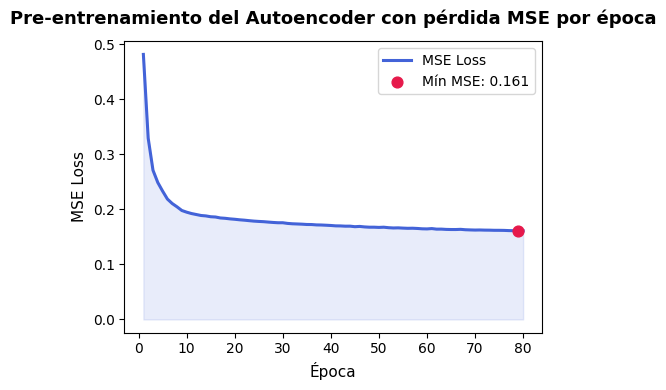

In [ ]:
#@title Validación de DEC
# * Quizá reducir el batch_size para el embedding
# ==============================================================================

if __name__ == "__main__":
    #
    labels_true = y_train
    labels_pred = dec.labels_
    pretrain_loss = pretrain_losses

    print(f"  Etiquetas verdaderas : {labels_true.shape}  clases únicas: {np.unique(labels_true)}")
    print(f"  Etiquetas predichas : {labels_pred.shape}  clusters únicos: {np.unique(labels_pred)}")
    print(f"  Pérdida en preentrenamiento del autoencoder: {len(pretrain_loss)} épocas  "
      f"(inicio={pretrain_loss[0]:.5f}, fin={pretrain_loss[-1]:.5f})")

    # Gráfico de pérdida
    grafico_perdida(pretrain_loss)

    # Cargar embedding ---------------------------------------------------------
    # embedding = cargar_embeddings()
    X_t = torch.from_numpy(X_train).float()
    ldr = DataLoader(torch.utils.data.TensorDataset(X_t), batch_size=2048, shuffle=False)

    autoencoder = dec.neural_network
    autoencoder = autoencoder.to(DEVICE)
    autoencoder.eval()    # Ponemos el autoencoder en modo de evaluación

    embs = []
    with torch.no_grad():
        for (batch,) in ldr:
            batch = batch.to(DEVICE)
            embs.append(autoencoder.encode(batch).cpu().numpy())
    embedding = np.concatenate(embs)

    # Métricas de validación ---------------------------------------------------
    met_ext = metricas_externas(labels_true, labels_pred)
    met_int = metricas_internas(embedding, labels_pred, len(embedding)) #, n_muestra=len(embedding))

Calculando t-SNE sobre 10000 puntos...


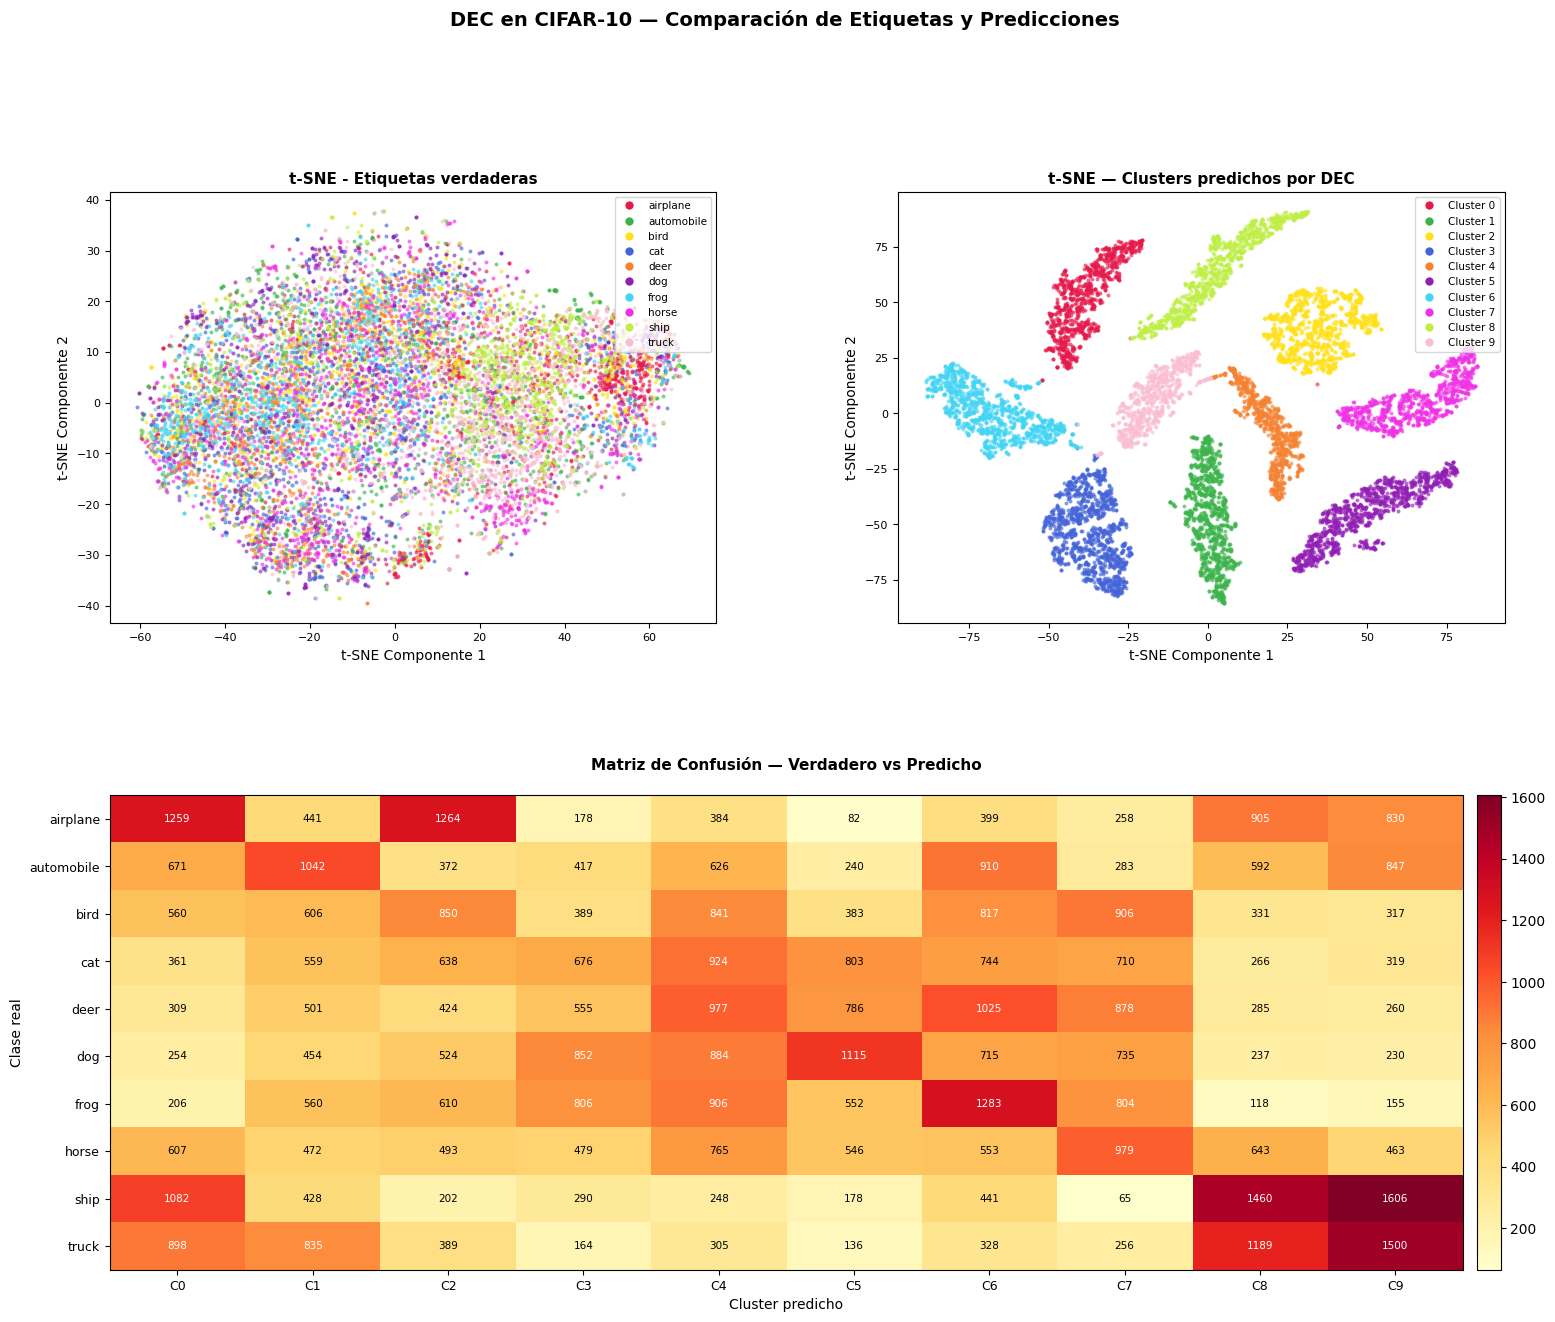

In [ ]:
clases_CIFAR10 = ["airplane", "automobile", "bird", "cat", "deer",
                  "dog", "frog", "horse", "ship", "truck"]

# Gráfico de etiquetas con TSNE
grafico_TSNE_etiquetas(embedding, X_train,
                    labels_true, labels_pred, clases_CIFAR10, n_muestra=10000)

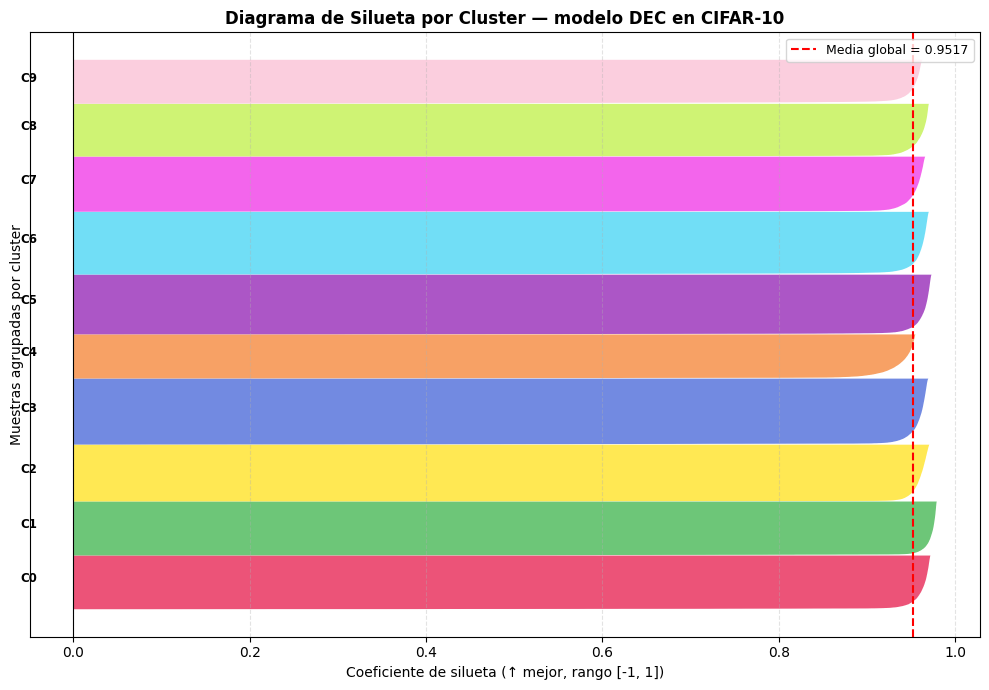

In [ ]:
grafico_silueta_cluster(embedding, labels_pred, model_name='DEC')

# Modelo IDEC



In [ ]:
#@title Entrenamiento modelo IDEC
# * Probar autoencoder con dropout y batch_norm
# * Probar otros autoencoders
# * Reducir batch_size, y añadir weight_decay
# * Cambiar optimizador de Clustering y parámetros
# * Probar otros algoritmos de agrupamiento en DEC
# =============================================================================

if __name__ == "__main__":
    #
    # Carga de datos
    X_train_IDEC, y_train_IDEC = cargar_cifar10(batch_size=2048)

    # Normalización antes del entrenamiento del autoencoder para estabilizar el gradiente
    X_train_IDEC = z_normalization(X_train_IDEC)
    print(f"X normalizado — media: {X_train_IDEC.mean():.4f}  std: {X_train_IDEC.std():.4f}")

    # Construcción del autoencoder
    emb_size = 32
    autoencoder_IDEC = crear_autoencoder(
        FeedforwardAutoencoder,
        {
            "layers":        [3072, 1024, 512, 256, emb_size],
            "batch_norm":    False,
            "dropout":       None,
            "activation_fn": torch.nn.LeakyReLU,
        }
    )

    # Pre-entrenamiento manual del autoencoder con registro de pérdida
    print("\n[Fase 1] Pre-entrenamiento del autoencoder con registro de pérdida...")
    sincronizar_cuda()
    t0 = time.perf_counter()

    pretrain_losses_IDEC = pretrain_with_tracking(
        autoencoder = autoencoder_IDEC,
        X           = X_train_IDEC,
        n_epochs    = 60,
        batch_size  = 256,
        optimizer_class = torch.optim.AdamW,
        # optimizer_params = {"lr": 1e-3, 'weight_decay': 1e-6},
        optimizer_params = {"lr": 9e-4, 'weight_decay': 1e-6},
        loss_name = "MSE",
        use_scheduler = False
    )

    sincronizar_cuda()
    tf = time.perf_counter()

    print('  Tiempo de pre-entrenamiento:', formatear_tiempo(tf-t0))

    # DEC: Fase de clustering (KMeans por defecto)
    print("\n[Fase 2] Clustering IDEC (KL loss + reconstrucción) con KMeans...")
    idec = IDEC(
        n_clusters                  = 10,
        batch_size                  = 256,
        pretrain_epochs             = 0,            # Ya que el autoencoder se entrenó manualmente
        clustering_epochs           = 140,
        # pretrain_optimizer_params   = {"lr": 1e-3},
        optimizer_class             = torch.optim.AdamW,
        # clustering_optimizer_params = {"lr": 5e-5},
        clustering_optimizer_params = {"lr": 8e-5, 'weight_decay': 1e-7},
        embedding_size              = emb_size,
        neural_network              = autoencoder_IDEC,
        # ssl_loss_weight             = 0.5,          # γ: Regularización en pérdida por reconstrucción
        ssl_loss_weight             = 0.4,          # γ: Regularización en pérdida por reconstrucción
        device                      = DEVICE,
        random_state                = seed
    )
    sincronizar_cuda()
    t0 = time.perf_counter()
    idec.fit(X_train_IDEC)            # Entrenamiento de DEC
    sincronizar_cuda()
    tf = time.perf_counter()

    print('  Tiempo de clustering con IDEC:', formatear_tiempo(tf-t0))

    # Inspección de resultados
    print("\n----- Distribución de clusters predichos -----")
    unique, counts = np.unique(idec.labels_, return_counts=True)
    for u, c in zip(unique, counts):
        barra = "█"*(c//400)
        print(f"  Cluster {u:2d}: {c:5d} muestras  {barra}")

    # ── 4.7 Persistencia ──────────────────────────────────────────────────────
    np.save("cifar10_labels_pred_IDEC.npy", idec.labels_)
    np.save("cifar10_labels_true_IDEC.npy", y_train_IDEC)
    # np.save("cifar10_pretrain_losses.npy", np.array(pretrain_losses))
    np.save("cifar10_pretrain_losses_IDEC.npy", pretrain_losses_IDEC)
    torch.save(idec.neural_network.state_dict(), "cifar10_autoencoder_IDEC.pt")

    print("\nArchivos guardados:")
    print("  cifar10_labels_pred_IDEC.npy      — etiquetas predichas")
    print("  cifar10_labels_true_IDEC.npy      — etiquetas reales")
    print("  cifar10_pretrain_losses_IDEC.npy  — pérdida MSE por época")
    print("  cifar10_autoencoder_IDEC.pt       — pesos del autoencoder")
    print("\nModelo listo para la fase de validacion.")

CIFAR-10 cargado — X: (60000, 3072)  y: (60000,)
X normalizado — media: -0.0000  std: 1.0000
FeedforwardAutoencoder — parámetros totales: 7,625,248

[Fase 1] Pre-entrenamiento del autoencoder con registro de pérdida...
  [Pretrain] Época   1/60  MSE: 0.481468
  [Pretrain] Época  10/60  MSE: 0.196247
  [Pretrain] Época  20/60  MSE: 0.182819
  [Pretrain] Época  30/60  MSE: 0.176323
  [Pretrain] Época  40/60  MSE: 0.171305
  [Pretrain] Época  50/60  MSE: 0.167393
  [Pretrain] Época  60/60  MSE: 0.164819
  Tiempo de pre-entrenamiento: 1 min 47.66 s

[Fase 2] Clustering IDEC (KL loss + reconstrucción) con KMeans...


DEC training: 100%|██████████| 140/140 [03:53<00:00,  1.67s/it, Loss=17.2]


  Tiempo de clustering con IDEC: 3 min 56.83 s

----- Distribución de clusters predichos -----
  Cluster  0:  6164 muestras  ███████████████
  Cluster  1:  6935 muestras  █████████████████
  Cluster  2:  4550 muestras  ███████████
  Cluster  3:  4026 muestras  ██████████
  Cluster  4:  5376 muestras  █████████████
  Cluster  5:  7129 muestras  █████████████████
  Cluster  6: 10548 muestras  ██████████████████████████
  Cluster  7:  5337 muestras  █████████████
  Cluster  8:  5013 muestras  ████████████
  Cluster  9:  4922 muestras  ████████████

Archivos guardados:
  cifar10_labels_pred_IDEC.npy      — etiquetas predichas
  cifar10_labels_true_IDEC.npy      — etiquetas reales
  cifar10_pretrain_losses_IDEC.npy  — pérdida MSE por época
  cifar10_autoencoder_IDEC.pt       — pesos del autoencoder

Modelo listo para la fase de validacion.


  Etiquetas verdaderas : (60000,)  clases únicas: [0 1 2 3 4 5 6 7 8 9]
  Etiquetas predichas : (60000,)  clusters únicos: [0 1 2 3 4 5 6 7 8 9]
  Pérdida en preentrenamiento del autoencoder: 60 épocas  (inicio=0.48147, fin=0.16482)
────────────────────────────────────────────────────────────────
  MÉTRICAS EXTERNAS    RANGO          VALOR      DESCRIPCIÓN
────────────────────────────────────────────────────────────────
  ACC  (clustpy)       [0,1]          0.2000     Proporción de instancias correctamente asignadas
  PUR  (clustpy)       [0,1]          0.2180     Fracción de puntos de la clase dominante por cluster
  HOM  (sklearn)       [0,1]          0.0755     Cada cluster contiene solo puntos de una clase?
  COM  (sklearn)       [0,1]          0.0768     Todos los puntos de una clase están en el mismo cluster?
  VME  (sklearn)       [0,1]          0.0761     Media armónica de homogeneity y completeness
  NMI  (sklearn)       [0,1]          0.0761     Información mutua normalizada 

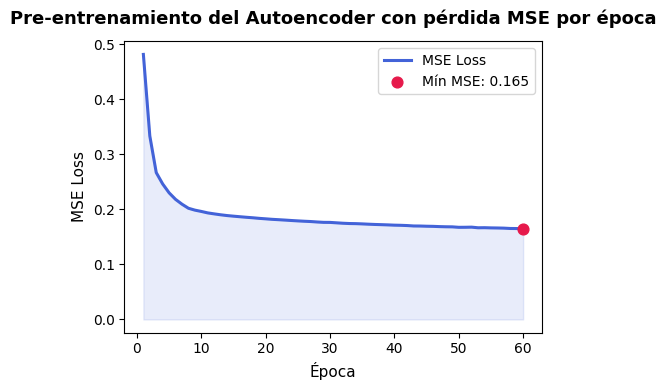

In [ ]:
#@title Validación de IDEC
# * Quizá reducir el batch_size para el embedding
# ==============================================================================

if __name__ == "__main__":
    #
    labels_true_IDEC = y_train_IDEC
    labels_pred_IDEC = idec.labels_
    pretrain_loss_IDEC = pretrain_losses_IDEC

    print(f"  Etiquetas verdaderas : {labels_true_IDEC.shape}  clases únicas: {np.unique(labels_true_IDEC)}")
    print(f"  Etiquetas predichas : {labels_pred_IDEC.shape}  clusters únicos: {np.unique(labels_pred_IDEC)}")
    print(f"  Pérdida en preentrenamiento del autoencoder: {len(pretrain_loss_IDEC)} épocas  "
      f"(inicio={pretrain_loss_IDEC[0]:.5f}, fin={pretrain_loss_IDEC[-1]:.5f})")

    # Gráfico de pérdida
    grafico_perdida(pretrain_loss_IDEC)

    # Cargar embedding ---------------------------------------------------------
    # embedding = cargar_embeddings()
    X_t = torch.from_numpy(X_train_IDEC).float()
    ldr = DataLoader(torch.utils.data.TensorDataset(X_t), batch_size=1024, shuffle=False)

    autoencoder_IDEC = idec.neural_network
    autoencoder_IDEC = autoencoder_IDEC.to(DEVICE)
    autoencoder_IDEC.eval()    # Ponemos el autoencoder en modo de evaluación

    sincronizar_cuda()
    t0 = time.perf_counter()

    embs = []
    with torch.no_grad():
        for (batch,) in ldr:
            batch = batch.to(DEVICE)
            embs.append(autoencoder_IDEC.encode(batch).cpu().numpy())
    embedding_IDEC = np.concatenate(embs)

    # Métricas de validación ---------------------------------------------------
    met_ext = metricas_externas(labels_true_IDEC, labels_pred_IDEC)
    met_int = metricas_internas(embedding_IDEC, labels_pred_IDEC, len(embedding_IDEC))

    sincronizar_cuda()
    tf = time.perf_counter()
    print('  Tiempo de embedding y cálculo de métricas:', formatear_tiempo(tf-t0))

Calculando t-SNE sobre 10000 puntos...
  Tiempo de gráfico TSNE: 4 min 21.22 s


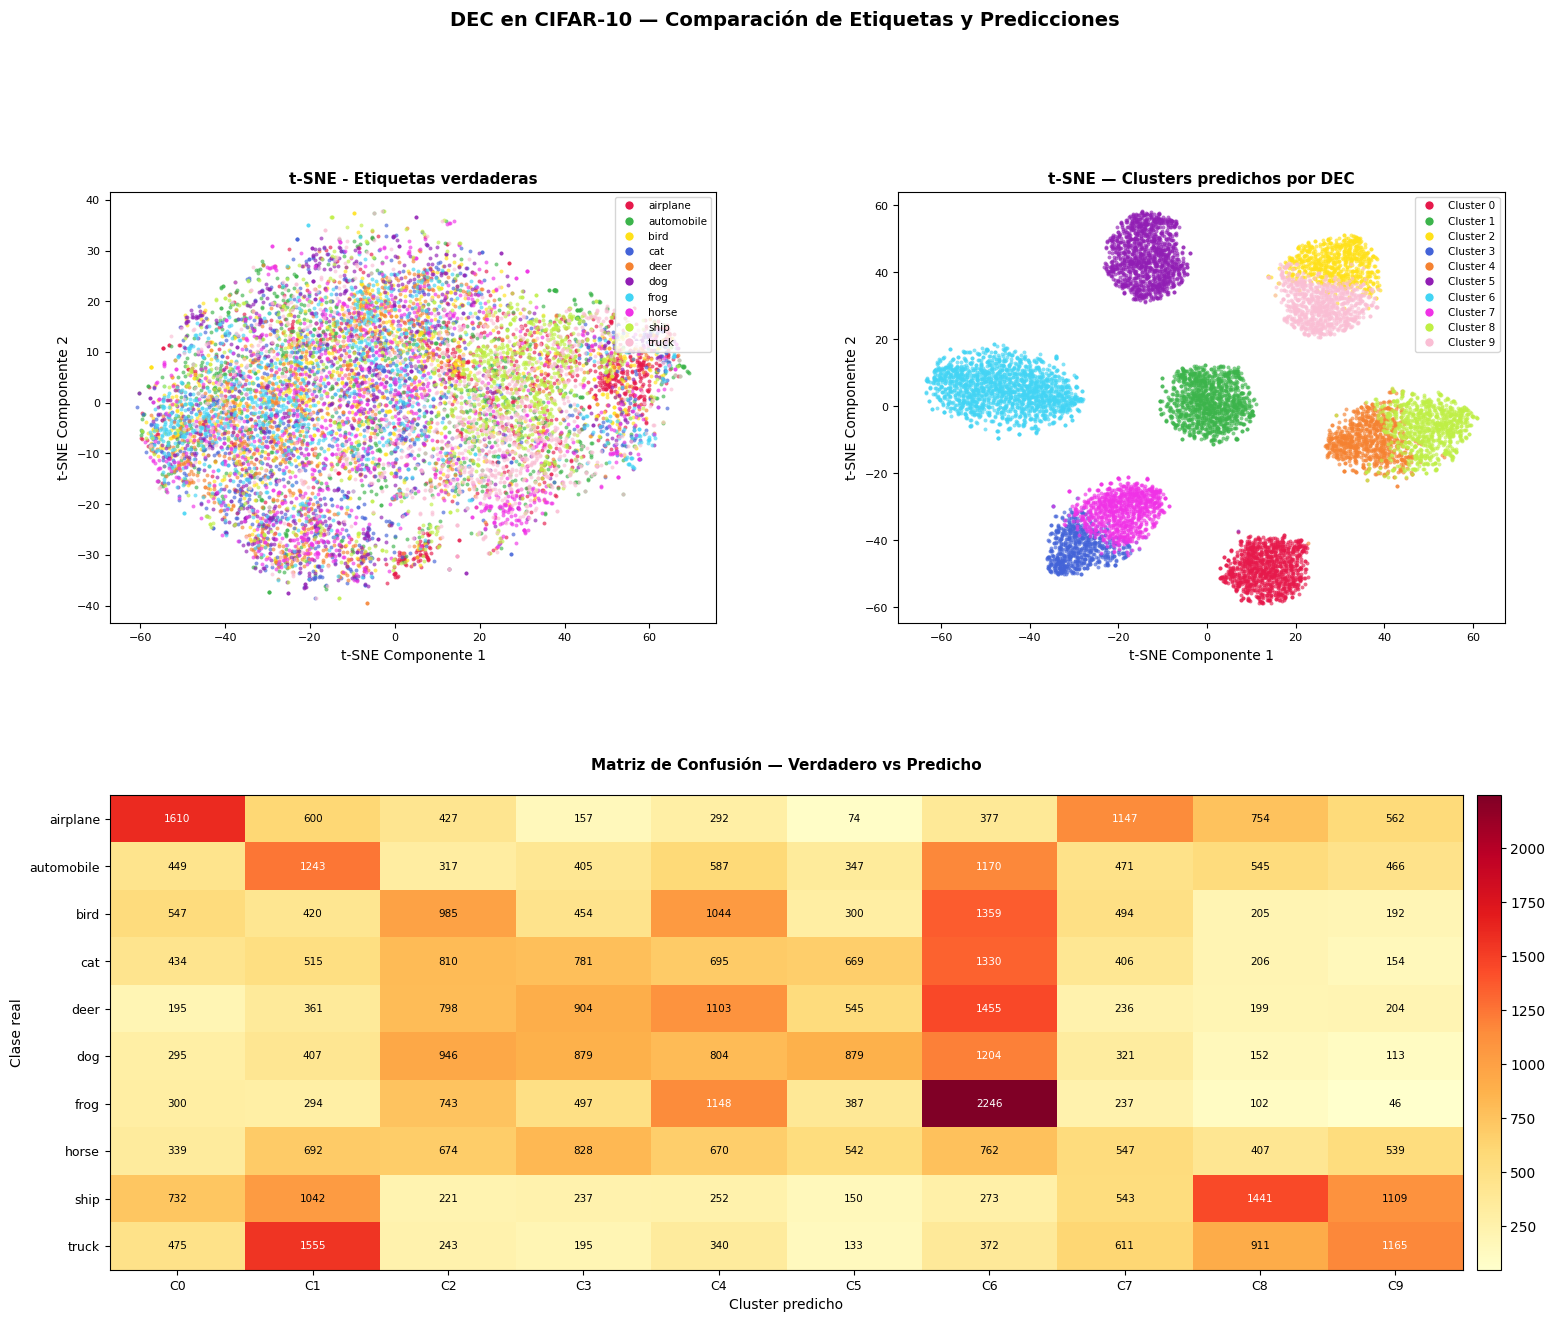

In [ ]:
clases_CIFAR10 = ["airplane", "automobile", "bird", "cat", "deer",
                  "dog", "frog", "horse", "ship", "truck"]

sincronizar_cuda()
t0 = time.perf_counter()

# Gráfico de etiquetas con TSNE
grafico_TSNE_etiquetas(embedding_IDEC, X_train_IDEC,
                    labels_true_IDEC, labels_pred_IDEC, clases_CIFAR10, n_muestra=10000)

sincronizar_cuda()
tf = time.perf_counter()
print('  Tiempo de gráfico TSNE:', formatear_tiempo(tf-t0))

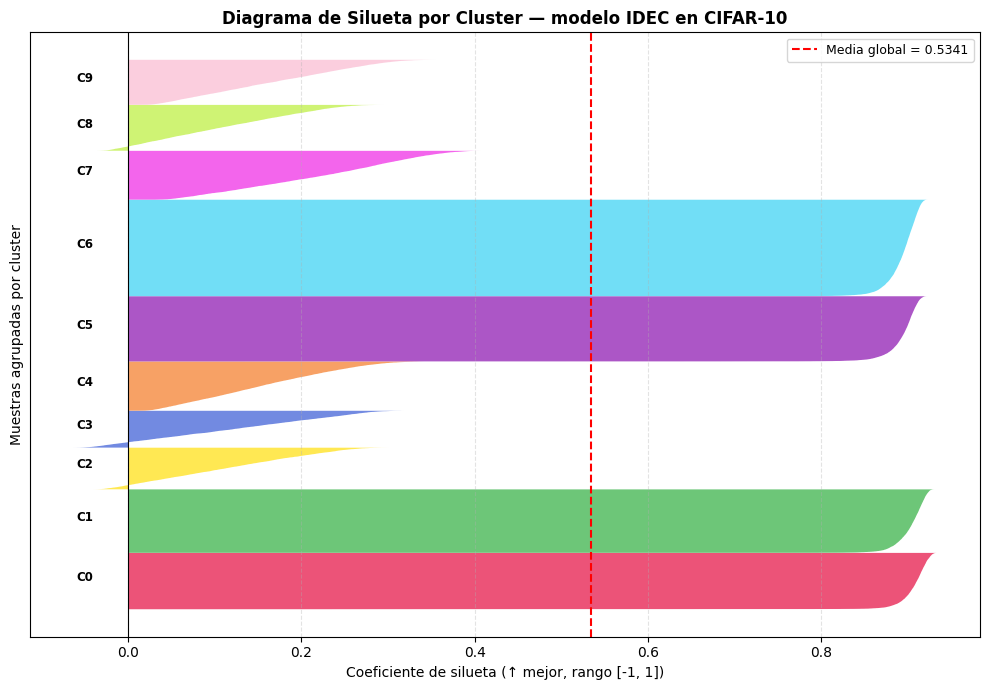

In [ ]:
grafico_silueta_cluster(embedding_IDEC, labels_pred_IDEC, model_name='IDEC')